In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles, LinearAlgebra;

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


In [92]:
#export_hwannier("wannier");
#export_momentum("wannier");
export_hwannier("../../Wannier /wannier");
export_momentum("../../Wannier /wannier");

#export_hwannier("../hBN33/wannier");
#export_momentum("../hBN33/wannier");


In [93]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
Hwannier33, cell_map33 = hwannier("../hBN33/wannier"), np.loadtxt("../hBN33/wannier.map.txt");
primitive_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/hBN_Optimization/Wannier "
Pwannier = pwannier("wannier")
Pwannier33 = pwannier("../hBN33/wannier")
Pwannier_primitive = pwannier(primitive_dir*"/wannier")
Hwannier_primitive, cell_map_primitive = hwannier(primitive_dir*"/wannier"), np.loadtxt(primitive_dir*"/wannier.map.txt");
lattice_vectors = loadlattice("wannier.out")
lattice_vectors33 = loadlattice("../hBN33/wannier.out")
primitive_lattice_vectors = loadlattice(primitive_dir*"/wannier.out");

In [109]:
#dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/hBN_Optimization/ab_initio_epsilon/"
dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/hBN_Optimization/ab_initio_epsilon/7bands/"
Qs = readlines(dir*"hBN.scattering.QMesh")[1:end]
Qs = [parse.(Float64, String.(split(Q))) for Q in Qs]
Qs = [unnormalize_kvector(primitive_lattice_vectors, Q) for Q in Qs[1:end-1]];
Qs = [norm(Q) for Q in Qs]
sort_perm_qs = sortperm(Qs)[1:20];

In [110]:
epsilons_abinitio = Float64[]
strict_2d_epsilons = Float64[]
G_perp = 2π/(40*bohrtoangstrom)

for idx in sort_perm_qs
    q = Qs[idx]
    iGarr = readlines(dir*"hBN.scattering.EpsilonBasis.$idx")
    Gs = [parse.(Int, split(x)) for x in iGarr]
    gamma_idx = findfirst(x->isequal(x, [0, 0, 0]), Gs)
    Gzs = findall(G->iszero(G[1]) && iszero(G[2]), Gs);
    numGs = length(Gs);
    epsilon = np.fromfile(dir*"hBN.scattering.Epsilon.$idx.0", dtype=np.complex)
    epsilon = np.reshape(epsilon, (numGs, numGs))
    epsilon_inv = inv(epsilon);
    
    Chi0 = np.fromfile(dir*"hBN.scattering.Chi0.$idx.0", dtype=np.complex)
    Chi0 = np.reshape(Chi0, (numGs, numGs));
    d = 3
    epsilon_2d_inv = 0
    for Gz in Gzs 
        G = Gs[Gz][3]*G_perp
        x = 2/(d*G)
        isinf(x) ? (epsilon_2d_inv += epsilon_inv[gamma_idx, Gz]) : (epsilon_2d_inv += x*sin(1/x)*epsilon_inv[gamma_idx, Gz])
    end
    push!(epsilons_abinitio, real(1/epsilon_2d_inv))
    strict_2d_epsilon = real(1 - (e²ϵ/(2*q))*Chi0[gamma_idx, gamma_idx]*40*eV/bohrtoangstrom^2)
    push!(strict_2d_epsilons, strict_2d_epsilon)
end
strict_2d_epsilons[1] = 1;

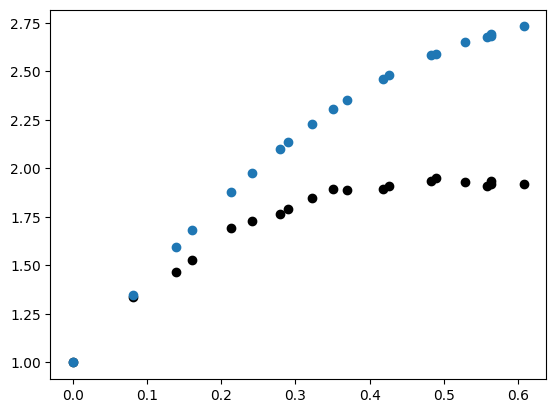

PyObject <matplotlib.collections.PathCollection object at 0x7f71d5d92370>

In [111]:
scatter(Qs[sort_perm_qs], epsilons_abinitio, color="black")
scatter(Qs[sort_perm_qs], strict_2d_epsilons)

#ylim(0, 2)
#xlim(0, 0.1)

In [112]:
idx = 2
(strict_2d_epsilons[idx]-strict_2d_epsilons[idx-1])/(Qs[sort_perm_qs[idx]]*bohrtoangstrom-Qs[sort_perm_qs[idx-1]]*bohrtoangstrom)

8.20217898651999

In [115]:
(epsilons_abinitio[idx]-epsilons_abinitio[idx-1])/(Qs[sort_perm_qs[idx]]*bohrtoangstrom-Qs[sort_perm_qs[idx-1]]*bohrtoangstrom)

7.9234308845652635

In [116]:
μ = -3
sigma_inter33 = interbandsigma(lattice_vectors33, Hwannier33, cell_map33, 
    Pwannier33, μ, Val(2); mesh=5, num_blocks = 5,
    histogram_width=10, energy_range=23, degeneracy=2);

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5


In [117]:
sigma_inter = interbandsigma(lattice_vectors, Hwannier, cell_map, 
    Pwannier, μ, Val(2); mesh=10, num_blocks = 20,
    histogram_width=10, energy_range=23, degeneracy=2);
sigma_inter_primitive = interbandsigma(primitive_lattice_vectors, Hwannier_primitive, cell_map_primitive, 
    Pwannier_primitive, μ, Val(2); mesh=10, num_blocks = 40,
    histogram_width=10, energy_range=23, degeneracy=2);

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40


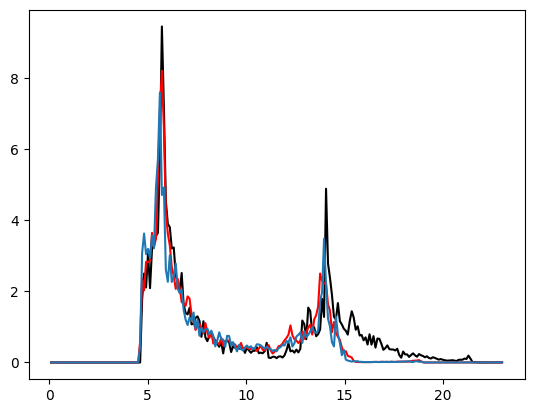

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f71d53ded60>

In [118]:
energies = range(0, 23, length=10*23)
plot(energies[2:end], smooth(real.(sigma_inter_primitive[1, 1, 2:end]), win_len=1), color="black")
plot(energies[2:end], smooth(real.(sigma_inter[1, 1, 2:end]), win_len=1), color="red")
plot(energies[2:end], smooth(real.(sigma_inter33[1, 1, 2:end]), win_len=1))


In [119]:
imag_conds = zeros(500)
imag_conds_primitive = zeros(500)
imag_conds_33 = zeros(500)

start_idx = 2
for i in 1:500
    imag_conds[i] = real(kramers_kronig(i*3/500, collect(range(0, 23, length=230))[start_idx:end], real.(sigma_inter[1, 1, start_idx:end]+sigma_inter[2, 2, start_idx:end]) ./ 2, Val(:real)))
    imag_conds_33[i] = real(kramers_kronig(i*3/500, collect(range(0, 23, length=230))[start_idx:end], real.(sigma_inter33[1, 1, start_idx:end]+sigma_inter33[2, 2, start_idx:end]) ./ 2, Val(:real)))
    imag_conds_primitive[i] = real(kramers_kronig(i*3/500, collect(range(0, 23, length=230))[start_idx:end], real.(sigma_inter_primitive[1, 1, start_idx:end]+sigma_inter_primitive[2, 2, start_idx:end]) ./ 2, Val(:real)))
end

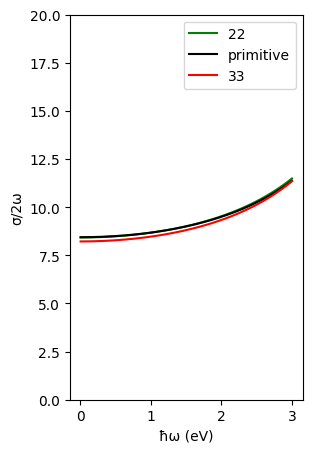

PyObject <matplotlib.legend.Legend object at 0x7f71d53a0e80>

In [120]:
figure(figsize=(3,5))
plot(collect(range(3/500, 3, length=500)), -1/bohrtoangstrom*e²ϵ/8*imag_conds ./  collect(range(3/500, 3, length=500)), color="green", label="22")
plot(collect(range(3/500, 3, length=500)), -1/bohrtoangstrom*e²ϵ/8*imag_conds_primitive ./  collect(range(3/500, 3, length=500)), color="black", label="primitive")
plot(collect(range(3/500, 3, length=500)), -1/bohrtoangstrom*e²ϵ/8*imag_conds_33 ./  collect(range(3/500, 3, length=500)), color="red", label="33")
xlabel("ħω (eV)")
ylim(0, 20)
ylabel("σ/2ω")
legend()

In [121]:
# Read wannier centers
line_num = 0
wannier_lines = readlines("wannier.out")
wannier_centers = zeros(28, 3)
for (idx, line) in enumerate(wannier_lines)
    line_num = idx
    contains(line, "Centers in lattice coords:") && break
end

for (idx, line) in enumerate(wannier_lines[line_num+1:end])
    try 
        x, y, z = parse.(Float64, split(line)[2:4])
        global wannier_centers[idx, :] = [x, y, z]
    catch
        break
    end
end

line_num = 0
wannier_lines = readlines("../../Wannier /wannier.out")
wannier_centers_primitive = zeros(7, 3)
for (idx, line) in enumerate(wannier_lines)
    line_num = idx
    contains(line, "Centers in lattice coords:") && break
end

for (idx, line) in enumerate(wannier_lines[line_num+1:end])
    try 
        x, y, z = parse.(Float64, split(line)[2:4])
        global wannier_centers_primitive[idx, :] = [x, y, z]
    catch e
        break
    end
end

line_num = 0
wannier_lines = readlines("../hBN33/wannier.out")
wannier_centers33 = zeros(63, 3)
for (idx, line) in enumerate(wannier_lines)
    line_num = idx
    contains(line, "Centers in lattice coords:") && break
end

for (idx, line) in enumerate(wannier_lines[line_num+1:end])
    try 
        x, y, z = parse.(Float64, split(line)[2:4])
        global wannier_centers33[idx, :] = [x, y, z]
    catch
        break
    end
end

In [122]:
function ImΠ_with_phases(wannier_centers::Array{Float64, 2}, Hwannier::Array{Float64, 3}, cell_map::Array{Float64, 2}, lattice_vectors::Vector{<:Vector{<:Real}}, q::Vector{<:Real}, μ::Real, dim::Val{D}=Val(2); 
    degeneracy::Integer=1, N::Integer=100, num_blocks::Integer=10, histogram_width::Integer=100, monte_carlo::Bool = false, verbose::Bool=true, normalized::Bool=true) where D

    verbose && println(q)
    Polarization_Array=zeros(histogram_width*100)
    V = 
        if D == 2 
            unit_cell_area(lattice_vectors) 
        elseif D ==3
            unit_cell_volume(lattice_vectors)
        end

    qnormalized = normalized ? q : normalize_kvector(lattice_vectors, q)

    numbands = size(Hwannier)[2]

    for _ in 1:num_blocks
        kpoints = !monte_carlo ? transpose(make_mesh(N, dim)) : vcat(rand(D, N^D), zeros(3-D, N^D))
        kphases = np.exp(-2π*1im*wannier_centers * kpoints)

        kplusqpoints = reshape(repeat(qnormalized, N^D), (3, N^D)) + kpoints
        kplusqphases = np.exp(-2π*1im*wannier_centers * kplusqpoints)

        Eks, Uks = wannier_bands(Hwannier, cell_map, kpoints)
        Ekqs, Ukqs = wannier_bands(Hwannier, cell_map, kplusqpoints)
        Uks_with_phases = np.einsum("il, lij-> lij ", kphases, Uks)
        Ukqs_with_phases = np.einsum("il, lij-> lij ", kplusqphases, Ukqs)

        overlaps = np.einsum("lji, ljk -> lik", np.conj(Uks_with_phases), Ukqs_with_phases) # l indexes the k point, i and k index the band indices
        overlaps = overlaps .* np.conj(overlaps) # lij component is |<i, k_l| j, k_l+q>|^2

        Ekqs_reshaped = np.repeat(np.reshape(Ekqs, (N^D, 1, numbands)), numbands, axis=1)
        Eks_reshaped = np.repeat(np.reshape(Eks, (N^D, numbands, 1)), numbands, axis=2)
        omegas = Ekqs_reshaped - Eks_reshaped # lij component is E(k_l + q)_j - E(k_l)_i

        f2 = np.heaviside(μ .- Ekqs_reshaped, 0.5)
        f1 = np.heaviside(μ .- Eks_reshaped, 0.5)

        summand = (f2 - f1) .* overlaps

        Polarization_Array += first(np.histogram(omegas, bins=round(Int, histogram_width*100), weights=summand, range=(0, 100)))*π/V*(1/N)^D*histogram_width*degeneracy*(1/num_blocks)
    end
    return Polarization_Array
end

ImΠ_with_phases (generic function with 2 methods)

In [123]:
#dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/hBN_Optimization/ab_initio_epsilon/"
# now that we have the ordering
kpoints = ([parse.(Float64, String.(split(Q))) for Q in readlines(dir*"hBN.scattering.QMesh")[1:end]])[sort_perm_qs];

In [124]:
#kpoints = bandstructkpoints2q(kpointsfile="../../Wannier /bandstruct.kpoints", interpolate=20);

polarizations = []
polarizations_primitive = []
polarizations33 = []
μ = -3
for (i,k) in enumerate(kpoints[1:10])
    println(i); flush(stdout)
    push!(polarizations_primitive, ImΠ_with_phases(wannier_centers_primitive, Hwannier_primitive, 
            cell_map_primitive, primitive_lattice_vectors, k, μ, Val(2), histogram_width=10, N=10, num_blocks=40, degeneracy=2, monte_carlo=true))
    push!(polarizations, ImΠ_with_phases(wannier_centers, Hwannier, cell_map, lattice_vectors, k*2, μ, Val(2), 
            histogram_width=10, N=8, num_blocks=20, degeneracy=2, monte_carlo=true))
    push!(polarizations33, ImΠ_with_phases(wannier_centers33, Hwannier33, cell_map33, lattice_vectors33, k*3, μ,
            Val(2), histogram_width=10, N=5, num_blocks=20, degeneracy=2, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
2
[-0.027778, 0.027778, 0.0]
[-0.055556, 0.055556, 0.0]
[-0.083334, 0.083334, 0.0]
3
[-0.055556, 0.027778, 0.0]
[-0.111112, 0.055556, 0.0]
[-0.166668, 0.083334, 0.0]
4
[0.0, -0.055556, 0.0]
[0.0, -0.111112, 0.0]
[0.0, -0.166668, 0.0]
5
[0.027778, -0.083333, 0.0]
[0.055556, -0.166666, 0.0]
[0.083334, -0.24999900000000003, 0.0]
6
[0.083333, 0.0, 0.0]
[0.166666, 0.0, 0.0]
[0.24999900000000003, 0.0, 0.0]
7
[0.055556, -0.111111, 0.0]
[0.111112, -0.222222, 0.0]
[0.166668, -0.333333, 0.0]
8
[0.111111, -0.027778, 0.0]
[0.222222, -0.055556, 0.0]
[0.333333, -0.083334, 0.0]
9
[-0.111111, 0.111111, 0.0]
[-0.222222, 0.222222, 0.0]
[-0.333333, 0.333333, 0.0]
10
[0.055556, 0.083333, 0.0]
[0.111112, 0.166666, 0.0]
[0.166668, 0.24999900000000003, 0.0]


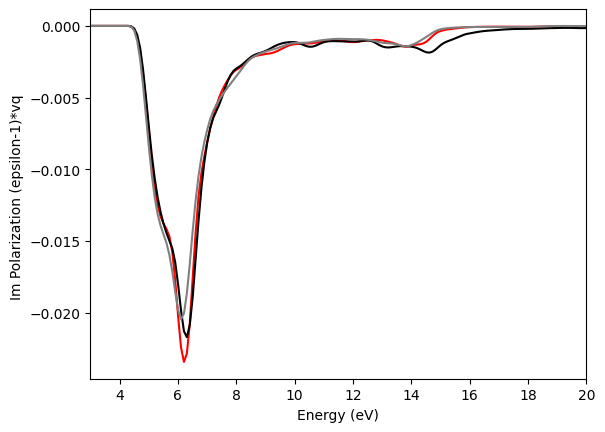

PyObject Text(24.0, 0.5, 'Im Polarization (epsilon-1)*vq ')

In [125]:
energies = range(0, 100, length=100*10)
idx = 10
plot(energies, smooth(real.(polarizations[idx]), win_len=10), color="red")
plot(energies, smooth(real.(polarizations_primitive[idx]), win_len=10), color="black")
plot(energies, smooth(real.(polarizations33[idx]), win_len=10), color="grey")

xlim(3, 20)
xlabel("Energy (eV)")
ylabel("Im Polarization (epsilon-1)*vq ")

In [126]:
qs = norm.(unnormalize_kvector.(Ref(primitive_lattice_vectors), kpoints)[1:10])*bohrtoangstrom;
epsilons = zeros(10, 200);
epsilons_primitive = zeros(10, 200);
epsilons33 = zeros(10, 200);

energies = collect(range(0, 100, length=1000))
for (i, k) in enumerate(kpoints[1:10])
    i == 1 && continue
    polarization = real.(polarizations[i])
    polarization33 = real.(polarizations33[i])
    polarization_primitive = real.(polarizations_primitive[i])
    for (j, ω) in enumerate(range(0.05, 2, length=200))
        epsilons[i, j] = real(ϵ(k * 2, lattice_vectors, ω, energies, smooth(real.(polarization), win_len=10), Val(2), Val(:default), limit=20, δ=0.01, normalized=true))
        epsilons33[i, j] = real(ϵ(k * 3, lattice_vectors33, ω, energies, smooth(real.(polarization33), win_len=10), Val(2), Val(:default), limit=20, δ=0.01, normalized=true))
        epsilons_primitive[i, j] = real(ϵ(k , primitive_lattice_vectors, ω, energies, smooth(real.(polarization_primitive), win_len=10), Val(2), Val(:default), limit=20, δ=0.01, normalized=true))
    end
end

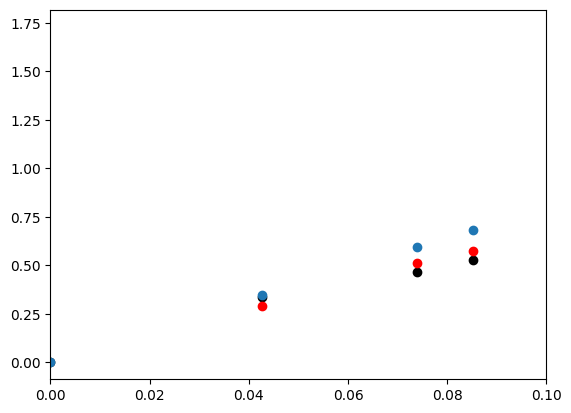

(0.0, 0.1)

In [130]:
scatter(Qs[sort_perm_qs]*bohrtoangstrom, epsilons_abinitio .-1, color="black")
scatter(Qs[sort_perm_qs]*bohrtoangstrom, strict_2d_epsilons .-1)
scatter(qs[2:end], epsilons_primitive[2:end, 1] .- 1, color="red")

xlim(0, 0.1)
#ylim(0, 0.3)